In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
# from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments
from transformers import T5Tokenizer, T5ForSequenceClassification, Trainer, TrainingArguments

from datasets import load_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import re

In [3]:
# =============================
# 2. Load Dataset (GLUE SST-2)
# =============================
dataset = load_dataset("glue", "sst2")
print(dataset)

# Show one sample
print("\nSample data:")
print(dataset['train'][0])

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

Sample data:
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


In [4]:
print(list(dataset['train']["label"]))

[0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 

In [5]:
print(list(dataset['validation']["label"]))

[1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 

In [6]:
# =============================
# 3. Preprocessing
# =============================
t5_tokenizer = T5Tokenizer.from_pretrained("google-t5/t5-base")

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
class SST2Dataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len=128):
    self.encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=max_len)
    self.labels = labels
  
  def __getitem__(self, idx):
     return {
         "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
         "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
         "labels": torch.tensor(self.labels[idx])
     }

  def __len__(self):
    return len(self.labels)

In [8]:
train_ds = SST2Dataset(
    texts=list(dataset['train']["sentence"]),
    labels=list(dataset['train']["label"]),
    tokenizer=t5_tokenizer
)

val_ds = SST2Dataset(
    texts=list(dataset['validation']["sentence"]),
    labels=list(dataset['validation']["label"]),
    tokenizer=t5_tokenizer
)

test_ds = SST2Dataset(
    texts=list(dataset['test']["sentence"]),
    labels=list(dataset['test']["label"]),
    tokenizer=t5_tokenizer
)

In [9]:
print(len(train_ds), len(val_ds), len(test_ds))

67349 872 1821


In [10]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [11]:
print(len(train_loader), len(val_loader), len(test_loader))

2105 14 29


## Load model

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cuda


In [13]:
# =============================
# 4. Load Model
# =============================
t5_model = T5ForSequenceClassification.from_pretrained("google-t5/t5-base", num_labels=2).to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

T5ForSequenceClassification LOAD REPORT from: google-t5/t5-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.dense.bias      | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.out_proj.bias   | MISSING | 
classification_head.out_proj.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
print(t5_model)

T5ForSequenceClassification(
  (transformer): T5Model(
    (shared): Embedding(32128, 768)
    (encoder): T5Stack(
      (embed_tokens): Embedding(32128, 768)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=768, out_features=768, bias=False)
                (k): Linear(in_features=768, out_features=768, bias=False)
                (v): Linear(in_features=768, out_features=768, bias=False)
                (o): Linear(in_features=768, out_features=768, bias=False)
                (relative_attention_bias): Embedding(32, 12)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseActDense(
                (wi): Linear(in_features=768, out_features=3072, bias=False)
                (wo): Linear(in_feat

## Define metrics function

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate(model, dataloader, device, mode):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Evaluating {mode} dataset"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # overall accuracy
    acc = accuracy_score(all_labels, all_preds)

    # per-class precision, recall, f1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        labels=[0, 1],   # ensure order: negative (0), positive (1)
        average=None
    )

    return {
        "accuracy": acc,
        "precision_neg": precision[0],
        "recall_neg": recall[0],
        "f1_neg": f1[0],
        "precision_pos": precision[1],
        "recall_pos": recall[1],
        "f1_pos": f1[1],
    }

## Model performance before training

In [16]:
# import json
# before_val_acc = evaluate(t5_model, val_loader, device, "validation")
# print("\nBaseline validation accuracy:")
# print(json.dumps(before_val_acc, indent=4))

In [17]:
import json
before_train_acc = evaluate(t5_model, train_loader, device, "train")
before_val_acc = evaluate(t5_model, val_loader, device, "validation")

print("Baseline train accuracy:")
print(json.dumps(before_train_acc, indent=4))

print("\nBaseline validation accuracy:")
print(json.dumps(before_val_acc, indent=4))

Evaluating validation dataset: 100%|██████████| 14/14 [00:13<00:00,  1.01it/s]

Baseline train accuracy:
{
    "accuracy": 0.4420555613297896,
    "precision_neg": 0.4420753903986449,
    "recall_neg": 0.9990933512424446,
    "f1_neg": 0.612939443568905,
    "precision_pos": 0.41304347826086957,
    "recall_pos": 0.0005057361122201815,
    "f1_pos": 0.00101023527847933
}

Baseline validation accuracy:
{
    "accuracy": 0.4908256880733945,
    "precision_neg": 0.4908256880733945,
    "recall_neg": 1.0,
    "f1_neg": 0.6584615384615384,
    "precision_pos": 0.0,
    "recall_pos": 0.0,
    "f1_pos": 0.0
}



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Training

In [18]:
total_params = sum(p.numel() for p in t5_model.parameters())
trainable_params = sum(p.numel() for p in t5_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 223495682
Trainable parameters: 223495682


In [19]:
from sklearn.metrics import accuracy_score

optimizer = optim.AdamW(t5_model.parameters(), lr=1e-5)
epochs = 5

In [20]:
# ## Model performance before training
# t5_model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for batch in tqdm(val_loader, desc="Evaluating"):
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)
#         # print("Label: ", labels)
#         outputs = t5_model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#         )
#         # print(outputs.logits)
        
#         preds = torch.argmax(outputs.logits, dim=1)
#         # print(preds)
        
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())
#         # print(all_preds)
#         # print(all_labels)
#         # break
        
# # print("Pred:")
# # print(all_labels)

# acc = accuracy_score(all_labels, all_preds)
# print(f"\Validation accuracy: {acc:.4f}")

In [21]:
# evaluate(t5_model, test_loader, device, "test")

In [22]:
train_losses = []          # per batch
val_losses = []            # per batch
epoch_train_losses = []    # per epoch
epoch_val_losses = []      # per epoch

epoch_train_acc = []       # per epoch
epoch_val_acc = []	       # per epoch

In [23]:
for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    
    # Training mode
    t5_model.train()

    total_loss = 0

    for batch in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = t5_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        # 🔥 log batch loss
        train_losses.append(loss.item())

        total_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Training loss: {avg_train_loss:.4f}")
    epoch_train_losses.append(avg_train_loss)
    
    # Evaluation mode
    train_acc = evaluate(t5_model, train_loader, device, "train")
    print(f"\nTrain accuracy: {train_acc}")
    
    val_acc = evaluate(t5_model, val_loader, device, "validation")
    print(f"\nValidation accuracy: {val_acc}")
    
    epoch_train_acc.append(train_acc)
    epoch_val_acc.append(val_acc)


Epoch 1/5


Training: 100%|██████████| 2105/2105 [55:15<00:00,  1.57s/it]


Training loss: 0.2895


Evaluating train dataset: 100%|██████████| 2105/2105 [19:12<00:00,  1.83it/s]



Train accuracy: {'accuracy': 0.9514766366241518, 'precision_neg': np.float64(0.9488386266675696), 'recall_neg': np.float64(0.9410006715916722), 'f1_neg': np.float64(0.9449033954884176), 'precision_pos': np.float64(0.9535369562342986), 'recall_pos': np.float64(0.9597806702334372), 'f1_pos': np.float64(0.956648625703067)}


...

Training loss: 0.1058


Evaluating train dataset: 100%|██████████| 2105/2105 [19:13<00:00,  1.83it/s]



Train accuracy: {'accuracy': 0.9778764346909382, 'precision_neg': np.float64(0.9696526993824292), 'recall_neg': np.float64(0.980658159838818), 'f1_neg': np.float64(0.9751243781094527), 'precision_pos': np.float64(0.9845290215143294), 'recall_pos': np.float64(0.9756714312331976), 'f1_pos': np.float64(0.9800802139037433)}


Evaluating validation dataset: 100%|██████████| 14/14 [00:14<00:00,  1.03s/it]


Validation accuracy: {'accuracy': 0.9438073394495413, 'precision_neg': np.float64(0.9458823529411765), 'recall_neg': np.float64(0.9392523364485982), 'f1_neg': np.float64(0.9425556858147714), 'precision_pos': np.float64(0.941834451901566), 'recall_pos': np.float64(0.9481981981981982), 'f1_pos': np.float64(0.9450056116722784)}


In [24]:
# for epoch in range(epochs):
#     print(f"\nEpoch {epoch + 1}/{epochs}")
    
#     # Training mode
#     t5_model.train()

#     total_loss = 0

#     for batch in tqdm(train_loader, desc="Training"):
#         optimizer.zero_grad()

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)

#         # Forward pass
#         outputs = t5_model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             labels=labels
#         )

#         loss = outputs.loss

#         # 🔥 log batch loss
#         train_losses.append(loss.item())

#         total_loss += loss.item()

#         # Backward pass
#         loss.backward()
#         optimizer.step()

#     avg_train_loss = total_loss / len(train_loader)
#     print(f"Training loss: {avg_train_loss:.4f}")
#     epoch_train_losses.append(avg_train_loss)
    
#     # Evaluation mode
#     t5_model.eval()
#     all_preds = []
#     all_labels = []
#     total_val_loss = 0

#     with torch.no_grad():
#         for batch in tqdm(val_loader, desc="Evaluating"):
#             input_ids = batch["input_ids"].to(device)
#             attention_mask = batch["attention_mask"].to(device)
#             labels = batch["labels"].to(device)
    
#             outputs = t5_model(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask,
#             )

#             # loss = outputs.loss
        
#             # 🔥 log batch val loss
#             # val_losses.append(loss.item())

#             # total_val_loss += loss.item()

#             preds = torch.argmax(outputs.logits, dim=1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())

#     # avg_val_loss = total_val_loss / len(val_loader)
#     # epoch_val_losses.append(avg_val_loss)
#     # print(f"Validation loss: {avg_val_loss:.4f}")

#     acc = accuracy_score(all_labels, all_preds)
#     print(f"\nValidation accuracy: {acc:.4f}")

In [25]:
print("All epoch evaluation criteria:")
print("Train data:")
try:
    print(json.dumps(epoch_train_acc, indent=4))
except Exception:
    print(epoch_train_acc)

print("\nValidation data:")
try:
    print(json.dumps(epoch_val_acc, indent=4))
except Exception:
    print(epoch_val_acc)

All epoch evaluation criteria:
Train data:
[
    {
        "accuracy": 0.9514766366241518,
        "precision_neg": 0.9488386266675696,
        "recall_neg": 0.9410006715916722,
        "f1_neg": 0.9449033954884176,
        "precision_pos": 0.9535369562342986,
        "recall_pos": 0.9597806702334372,
        "f1_pos": 0.956648625703067
    },
    {
        "accuracy": 0.9636668695897489,
        "precision_neg": 0.9538103934916154,
        "recall_neg": 0.9645399597044997,
        "f1_neg": 0.9591451707154186,
        "precision_pos": 0.9716388247300854,
        "recall_pos": 0.9629747930474594,
        "f1_pos": 0.967287408259027
    },
    {
        "accuracy": 0.9694872975099853,
        "precision_neg": 0.9602882093169971,
        "recall_neg": 0.9711551376762928,
        "f1_neg": 0.9656911030602534,
        "precision_pos": 0.9769284486463258,
        "recall_pos": 0.9681652426202454,
        "f1_pos": 0.9725271052526036
    },
    {
        "accuracy": 0.9743574514840606,
     

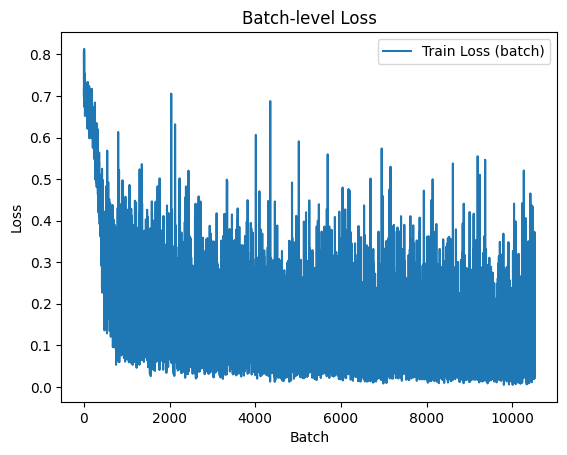

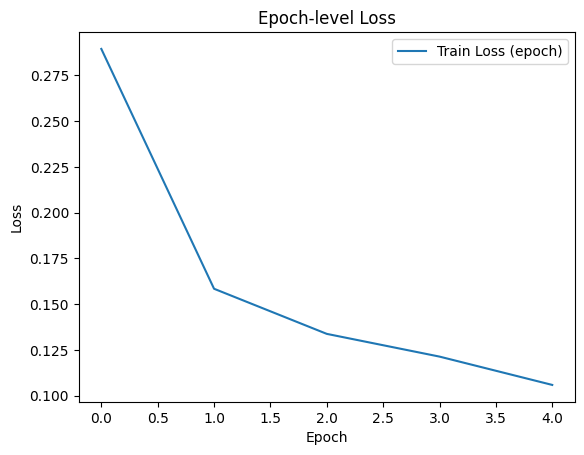

In [26]:
import matplotlib.pyplot as plt

# ---- Batch-level plot ----
plt.figure()
plt.plot(train_losses, label="Train Loss (batch)")
# plt.plot(val_losses, label="Val Loss (batch)")
plt.legend()
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Batch-level Loss")
plt.show()

# ---- Epoch-level plot ----
plt.figure()
plt.plot(epoch_train_losses, label="Train Loss (epoch)")
# plt.plot(epoch_val_losses, label="Val Loss (epoch)")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch-level Loss")
plt.show()

In [27]:
train_accuracy = [acc["accuracy"] for acc in epoch_train_acc]
val_accuracy = [acc["accuracy"] for acc in epoch_val_acc]

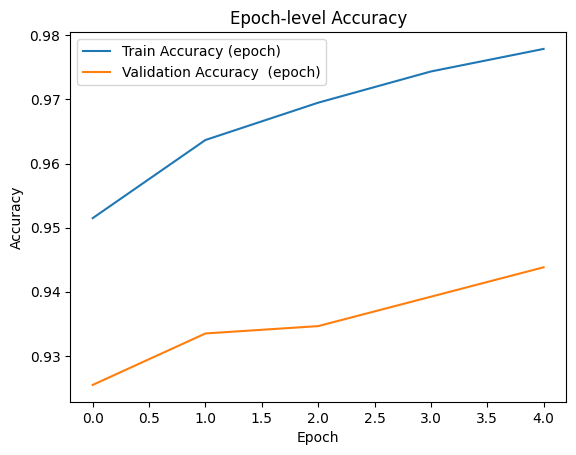

In [28]:
import matplotlib.pyplot as plt

# # ---- Batch-level plot ----
# plt.figure()
# plt.plot(train_accuracy, label="Train accuracy (batch)")
# # plt.plot(val_losses, label="Val Loss (batch)")
# plt.legend()
# plt.xlabel("Batch")
# plt.ylabel("Loss")
# plt.title("Batch-level Loss")
# plt.show()

# ---- Epoch-level plot ----
plt.figure()
plt.plot(train_accuracy, label="Train Accuracy (epoch)")
plt.plot(val_accuracy, label="Validation Accuracy  (epoch)")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch-level Accuracy")
plt.show()

In [29]:
print("After finetuning:")

print("\nTrain:")
print(json.dumps(epoch_train_acc[-1], indent=4))
print("\n\nValidation:")
print(json.dumps(epoch_val_acc[-1], indent=4))

After finetuning:

Train:
{
    "accuracy": 0.9778764346909382,
    "precision_neg": 0.9696526993824292,
    "recall_neg": 0.980658159838818,
    "f1_neg": 0.9751243781094527,
    "precision_pos": 0.9845290215143294,
    "recall_pos": 0.9756714312331976,
    "f1_pos": 0.9800802139037433
}


Validation:
{
    "accuracy": 0.9438073394495413,
    "precision_neg": 0.9458823529411765,
    "recall_neg": 0.9392523364485982,
    "f1_neg": 0.9425556858147714,
    "precision_pos": 0.941834451901566,
    "recall_pos": 0.9481981981981982,
    "f1_pos": 0.9450056116722784
}


In [30]:
# t5_model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for batch in tqdm(test_loader, desc="Evaluating"):
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["labels"].to(device)

#         outputs = t5_model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#         )

#         preds = torch.argmax(outputs.logits, dim=1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())
        
# print("Pred:")
# print(all_labels)

# acc = accuracy_score(all_labels, all_preds)
# print(f"\Test accuracy: {acc:.4f}")